<a href="https://colab.research.google.com/github/QuratulAin20/LLM-from-scratch/blob/main/LLM_from_scratch_Building_GPT(STEP3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STEP 3 OF BUILDING LLM FROM SCRATCH - BUILDING GPT

**Building Block of GPT architecture**

1. GPT backbone : here we build the placeholder GPT model to see over all model structure as DummyGptModel class.

> before building the class we first define our configuration

2. Layer Normalization : next we will define the component we have to use in our GPT model. The first is LayerNormalization .

3. Next we define activation function heer we are choosing GELU(non-linear activation function to add non-linearity in model)

4. Next define the feed forward network

5. define shortcut connection.

6. Define transformer block.

7. final GPT architetcture ready

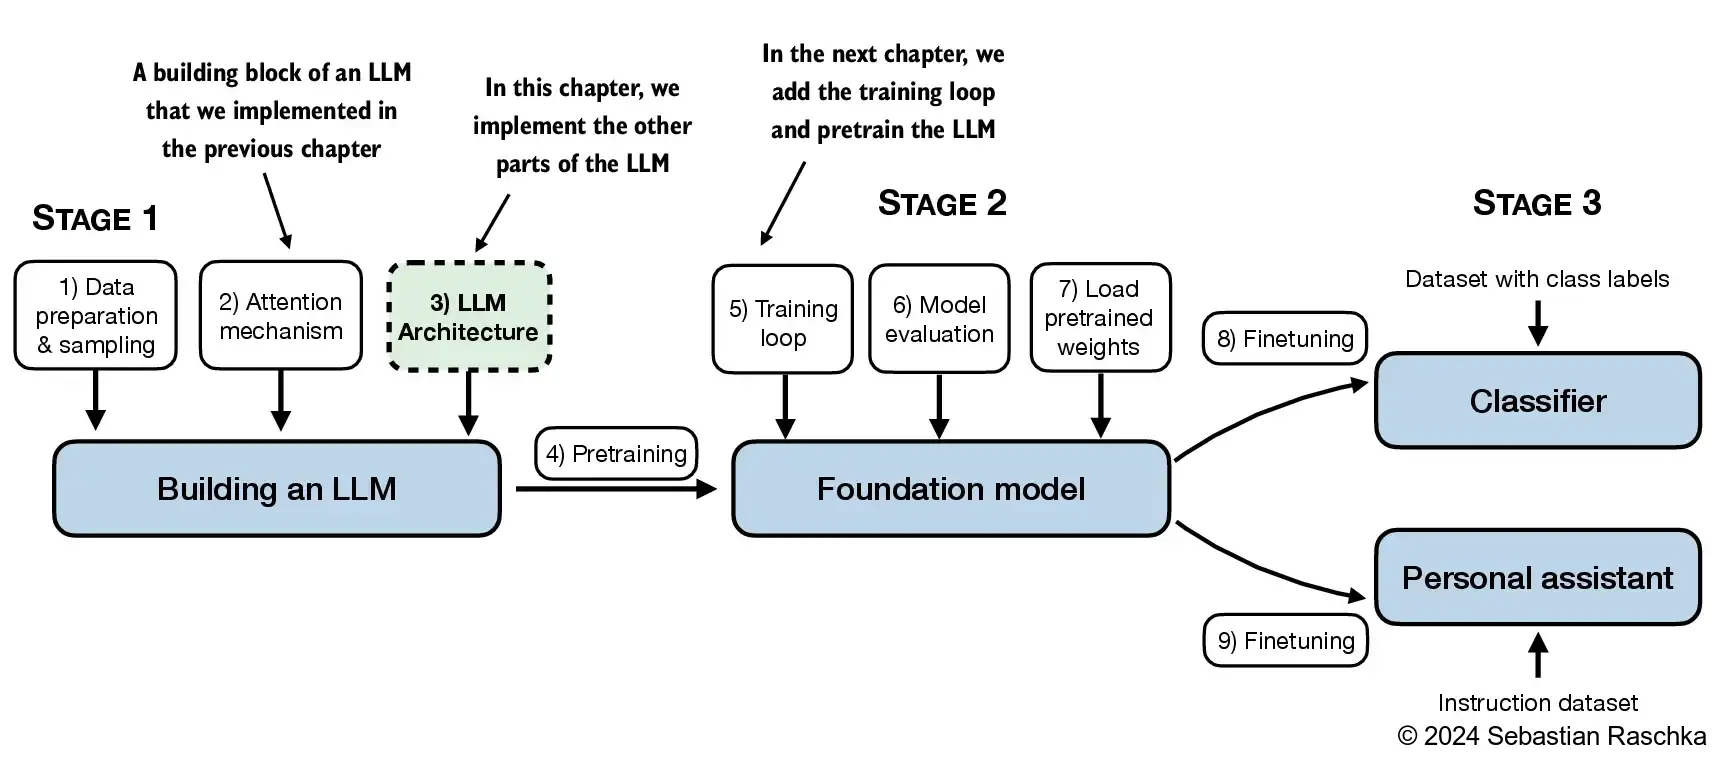

#### Chapter 4: Implementing a GPT model from Scratch To Generate Text

In [1]:
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.6 MB/s eta 0:00:00


In [2]:
from importlib.metadata import version

print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

matplotlib version: 3.10.0
torch version: 2.6.0+cu124
tiktoken version: 0.9.0


## 4.1 Coding an LLM architecture

Chapter 1 discussed models like GPT and Llama, which generate words sequentially and are based on the decoder part of the original transformer architecture.

Therefore, these LLMs are often referred to as "decoder-like" LLMs
Compared to conventional deep learning models, LLMs are larger, mainly due to their vast number of parameters, not the amount of code.

We'll see that many elements are repeated in an LLM's architecture

In previous chapters, we used small embedding dimensions for token inputs and outputs for ease of illustration, ensuring they fit on a single page
In this chapter, we consider embedding and model sizes akin to a small GPT-2 model.

We'll specifically code the architecture of the smallest GPT-2 model (124 million parameters), as outlined in Radford et al.'s Language Models are Unsupervised Multitask Learners (note that the initial report lists it as 117M parameters, but this was later corrected in the model weight repository).

Chapter 6 will show how to load pretrained weights into our implementation, which will be compatible with model sizes of 345, 762, and 1542 million parameters.

In [3]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers represent the no.of transfomer block we use
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

We use short variable names to avoid long lines of code later

`vocab_size` indicates a vocabulary size of 50,257 words, supported by the BPE tokenizer discussed in Chapter 2.

`context_length` represents the model's maximum input token count, as enabled by positional embeddings covered in Chapter 2.

`emb_dim` is the embedding size for token inputs, converting each input token into a 768-dimensional vector.

`n_heads` is the number of attention heads in the multi-head attention mechanism implemented in Chapter 3.

`n_layers` is the number of transformer blocks within the model, which we'll implement in upcoming sections.

`drop_rate` is the dropout mechanism's intensity, discussed in Chapter 3; 0.1 means dropping 10% of hidden units during training to mitigate overfitting.

`qkv_bias` decides if the Linear layers in the multi-head attention mechanism (from Chapter 3) should include a bias vector when computing query (Q), key (K), and value (V) tensors; we'll disable this option, which is standard practice in modern LLMs; however, we'll revisit this later when loading pretrained GPT-2 weights from OpenAI into our reimplementation in chapter 5

In [4]:

import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])          # input map from vocab_size to emb_dimension
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False          #output layer map from emb_dim to vocab_size this is how LLM generates text
        )                                                          # from vocab_size to embedding space and next from embedding space to vocab_size

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):   #placeholder code for transformer returning nothing now later we add mask multi-head attention
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):   # normalization layer
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

In [5]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = [] # batch an empty list that consist the 2 text

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


- here each word represent one token this is not the case always but here we do it for simplicity

- The Aim of LLM is to predict the next word

In [6]:
# initiate Dummy gpt model
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)  #output of model terminology is logits
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


**OUTPUT EXPLANATION**

- logits are the output of last layer here the output layer have input as emb_dim=786 and output size as vocab_size=50257
- 2 inputs
- 4 tokens in each coulmns or 4 features
- 50257 is the vocab_size i.e we get each vector with 50257 dimension

**How LLM predict the next letter**

- In training process we give an input as `every efforts move` then `you`vector must have the larget score among all in logits vector.
- Next we extract the largest score get the token ID.
- And use decode method to gte the next word

## 4.2 Normalizing activations with layer normalization

Layer normalization, also known as LayerNorm (Ba et al. 2016), centers the activations of a neural network layer around a mean of 0 and normalizes their variance to 1.

This stabilizes training and enables faster convergence to effective weights
Layer normalization is applied both before and after the multi-head attention module within the transformer block, which we will implement later; it's also applied before the final output layer.


Let's see how layer normalization works by passing a small input sample through a simple neural network laye

In [7]:
torch.manual_seed(123)

# create 2 training examples with 5 dimensions (features) each
batch_example = torch.randn(2, 5)

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())  #RELU is a non-linear activation function
out = layer(batch_example)
print(out)


tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


- `RELU` as it is non-linear function so it add non linearity in our model so that our model can also learn non-linearity with linear layers

In [ ]:
# let see the mean and variance
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


**WHY NORMALIZATION**

- To do optimal training mean some input values are too high some are too low. That not a good approach of training the model

Subtracting the mean and dividing by the square-root of the variance (standard deviation) centers the inputs to have a mean of 0 and a variance of 1 across the column (feature) dimension

In [ ]:
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Each input is centered at 0 and has a unit variance of 1; to improve readability, we can disable PyTorch's scientific notation

In [ ]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Above, we normalized the features of each input.

Now, using the same idea, we can implement a LayerNorm class

In [8]:
# building layernorm class
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var +  self.eps)
        return self.scale * norm_x + self.shift


🧪 Step-by-Step:
1. mean = x.mean(...)
🧮 This finds the average of numbers in each row (like finding the average size of cookies in a box).

2. var = x.var(...)
🔍 This tells us how different each cookie is from the average (like some are really big or really small).

3. norm_x = (x - mean) / sqrt(var + eps)
⚖️ This line balances everything! Now all cookies (numbers) have:

average = 0 🍪➖

same spread = 1 🎯

It’s like making sure all cookies are the same size and flavor!

4. self.scale and self.shift
👩‍🍳 After balancing, the AI says:

“Okay, I still want to add my secret sauce!”

So it uses scale (multiplying) and shift (adding) to adjust things a bit.



-----------


**Scale and shift**

Note that in addition to performing the normalization by subtracting the mean and dividing by the variance, we added two trainable parameters, a scale and a shift parameter

The initial scale (multiplying by 1) and shift (adding 0) values don't have any effect; however, scale and shift are trainable parameters that the LLM automatically adjusts during training if it is determined that doing so would improve the model's performance on its training task.

This allows the model to learn appropriate scaling and shifting that best suit the data it is processing.

Note that we also add a smaller value (eps) before computing the square root of the variance; this is to avoid division-by-zero errors if the variance is 0.

**Biased variance**

In the variance calculation above, setting unbiased=False means using the formula ()to compute the variance where n is the sample size (here, the number of features or columns); this formula does not include Bessel's correction (which uses n-1 in the denominator), thus providing a biased estimate of the variance.

For LLMs, where the embedding dimension n is very large, the difference between using n and n-1 is negligible

However, GPT-2 was trained with a biased variance in the normalization layers, which is why we also adopted this setting for compatibility reasons with the pretrained weights that we will load in later chapters

In [9]:
#Let's now try out LayerNorm in practice

ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)

In [10]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## 4.3 Implementing a feed forward network with GELU activations

In this section, we implement a small neural network sub module that is used as part of the transformer block in LLMs.

We start with the activation function:

In deep learning, ReLU (Rectified Linear Unit) activation functions are commonly used due to their simplicity and effectiveness in various neural network architectures.

In LLMs, various other types of activation functions are used beyond the traditional ReLU; two notable examples are `GELU (Gaussian Error Linear Unit)` and `SwiGLU (Swish-Gated Linear Unit)`

- GELU and SwiGLU are more complex, smooth activation functions incorporating Gaussian and sigmoid-gated linear units, respectively, offering better performance for deep learning models, unlike the simpler, piecewise linear function of ReLU
- GELU (Hendrycks and Gimpel 2016) can be implemented in several ways; the exact version is defined as GELU(x)=x⋅Φ(x), where Φ(x) is the cumulative distribution function of the standard Gaussian distribution.

In practice, it's common to implement a computationally cheaper approximation:

 (the original GPT-2 model was also trained with this approximation)


In [11]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

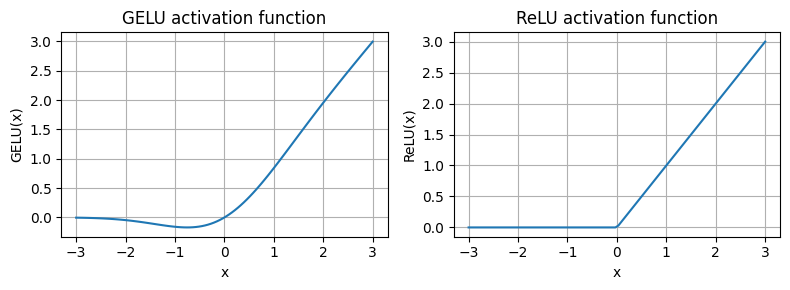

In [12]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

As we can see, ReLU is a piecewise linear function that outputs the input directly if it is positive; otherwise, it outputs zero

GELU is a smooth, non-linear function that approximates ReLU but with a non-zero gradient for negative values (except at approximately -0.75)

Next, let's implement the small neural network module, FeedForward, that we will be using in the LLM's transformer block later

In [13]:
# Creating Neural network use later
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)
print(GPT_CONFIG_124M["emb_dim"])


768


In [14]:
# Applying our neyral network
ffn = FeedForward(GPT_CONFIG_124M)

# input shape: [batch_size, num_token, emb_size]
x = torch.rand(2, 3, 768)   #lot of dimension to learn parameters correctly
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


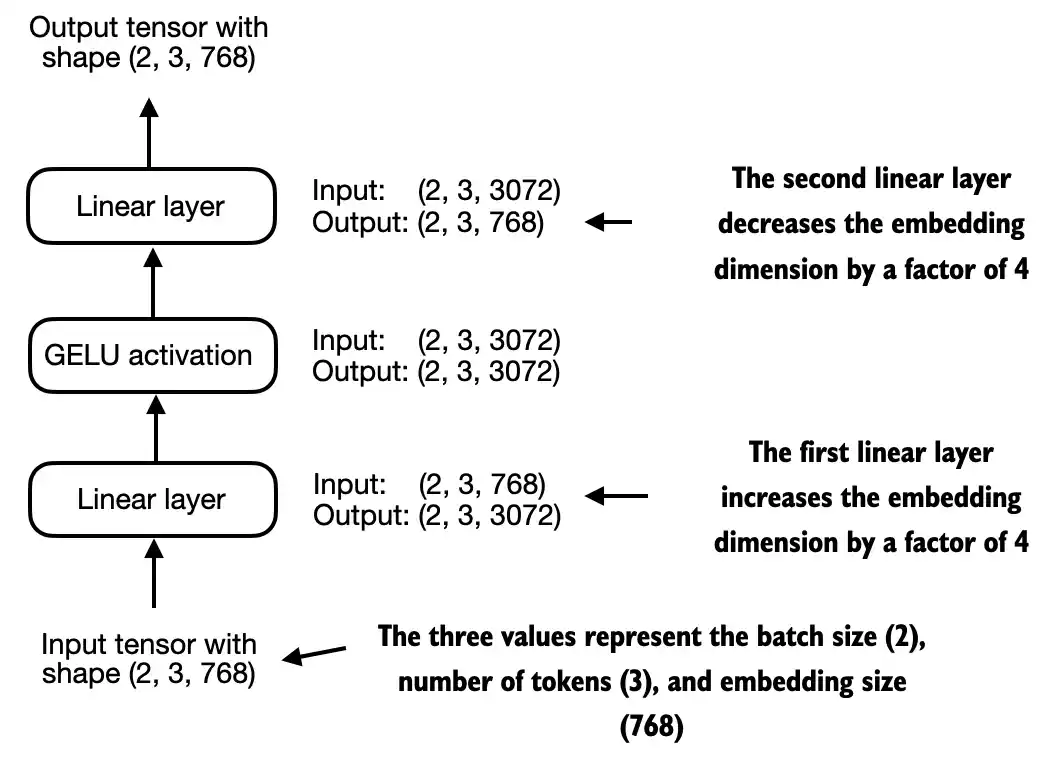

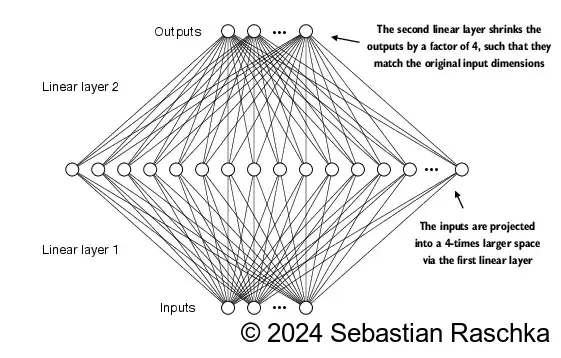

-------------------

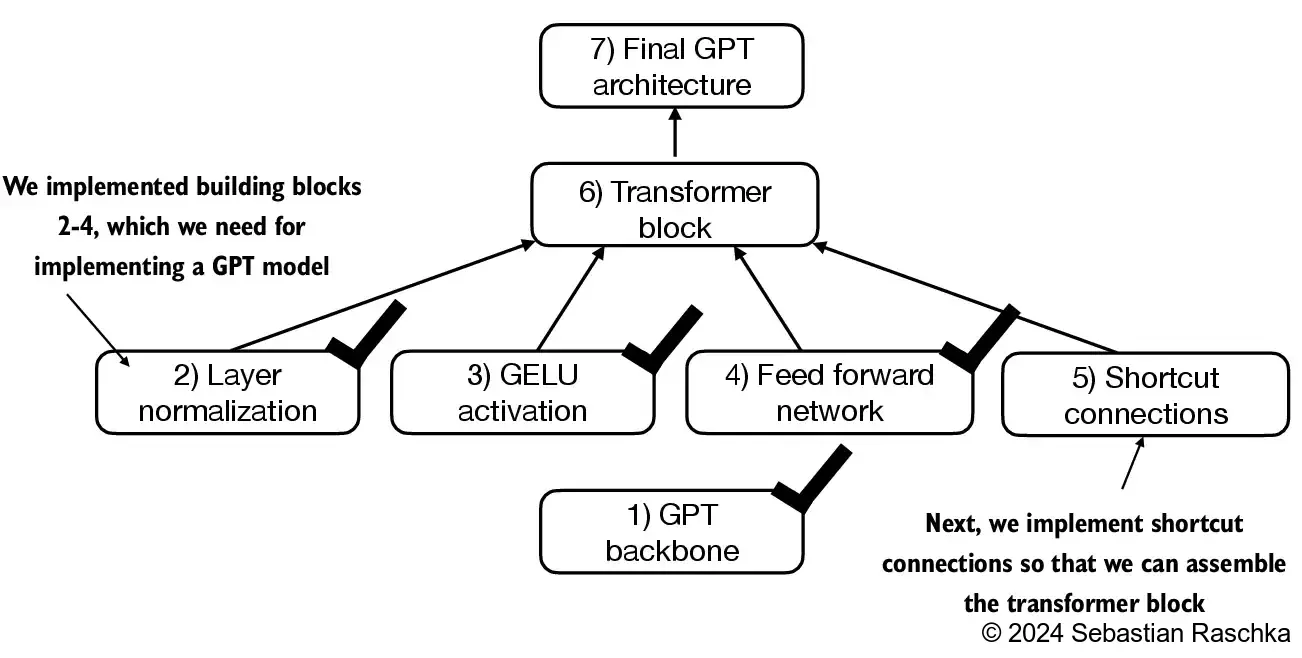

# 4.4 Adding shortcut/Residual connections

Next, let's talk about the concept behind shortcut connections, also called skip or residual connections.

Originally, shortcut connections were proposed in deep networks for computer vision (residual networks) to mitigate vanishing gradient problems.

A shortcut connection creates an alternative shorter path for the gradient to flow through the network. This is achieved by adding the output of one layer to the output of a later layer, usually skipping one or more layers in between

Let's illustrate this idea with a small example network

============================================

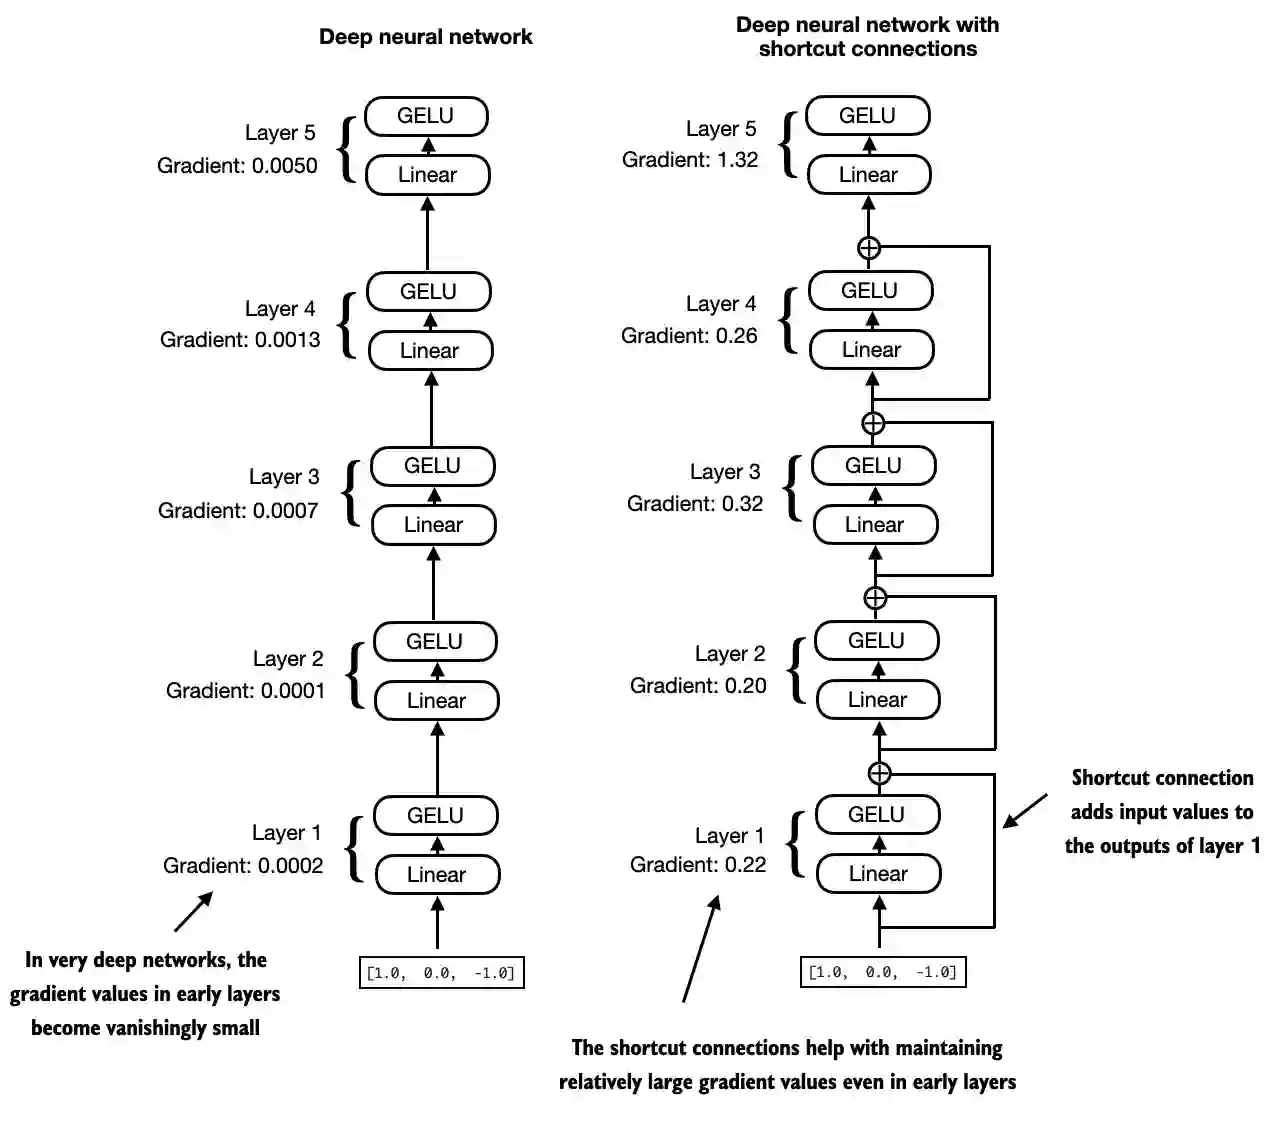

🧠 Imagine This:
You're doing your homework 📝, and it’s hard. So you ask your smart older sibling for help. But instead of rewriting your homework, they just add a few extra hints to help you solve it better.

That’s exactly what residual connections do for a robot brain (neural network). It’s like saying:

“Hey, instead of changing everything, let’s just add a helpful shortcut so we don’t forget the important stuff!”

🔄 What’s a Residual Connection?
It’s when the input (the thing you start with) is added directly to the output (the result after some changes). Like this:

text
Copy
Edit
Output = Layer(x) + x
It means: "Do something with x, but also keep x around — just in case."

🍔 Burger Analogy:
Think of a burger 🍔:

x = plain bun

Layer(x) = bun + patty + cheese

Residual Connection = plain bun + (bun + patty + cheese)

Now the burger has everything, including the original bun again — it’s even better!

🧠 Why Is This Useful?
Sometimes, when the robot brain (AI) gets very deep (lots of layers), it forgets what it saw earlier.

Residual connections say:

"Don't forget where you came from, just add to it!"

This helps the AI:

Learn faster 🏃‍♂️

Remember better 🧠

Make fewer mistakes 🚫

🖼️ Picture It Like:
text
Copy
Edit
[INPUT] ---> [LAYER] ---> (+) ---> [OUTPUT]
   |____________________|
         Shortcut
That curved line is the shortcut path that skips the work and just adds the original back in. Like a secret tunnel! 🕳️🚇

================================================================================

🔁 What Is a Residual Connection?
In deep learning, a residual connection (also called a shortcut connection) is when you add the input of a layer directly to its output.

Instead of just doing:

```
output = Layer(x)
```
You do:
```
output = Layer(x) + x
```

🧠 Why Do We Do This?
As neural networks get deeper (more layers), they can become harder to train. Problems like:

- Vanishing gradients (learning slows down)

- Overfitting

- Losing important information

Residual connections solve this by letting the network "skip" some layers. It helps the model keep the original information and only add small improvements (called “residuals”).



-----
-----

In [15]:
#In code, it looks like this:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)

    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

Let's print the gradient values first without shortcut connections

In [16]:
layer_sizes = [3, 3, 3, 3, 3, 1]

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


In [17]:
#Next, let's print the gradient values with shortcut connections it will maximize value

torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)


layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


As we can see based on the output above, shortcut connections prevent the gradients from vanishing in the early layers (towards layer.0)

We will use this concept of a shortcut connection next when we implement a transformer block

## 4.5 Connecting attention and linear layers in a transformer block

- we have done with all the component of GPT next we have an important block that is transformer block

- Modern GPT doesnot use encoder only use decoder block

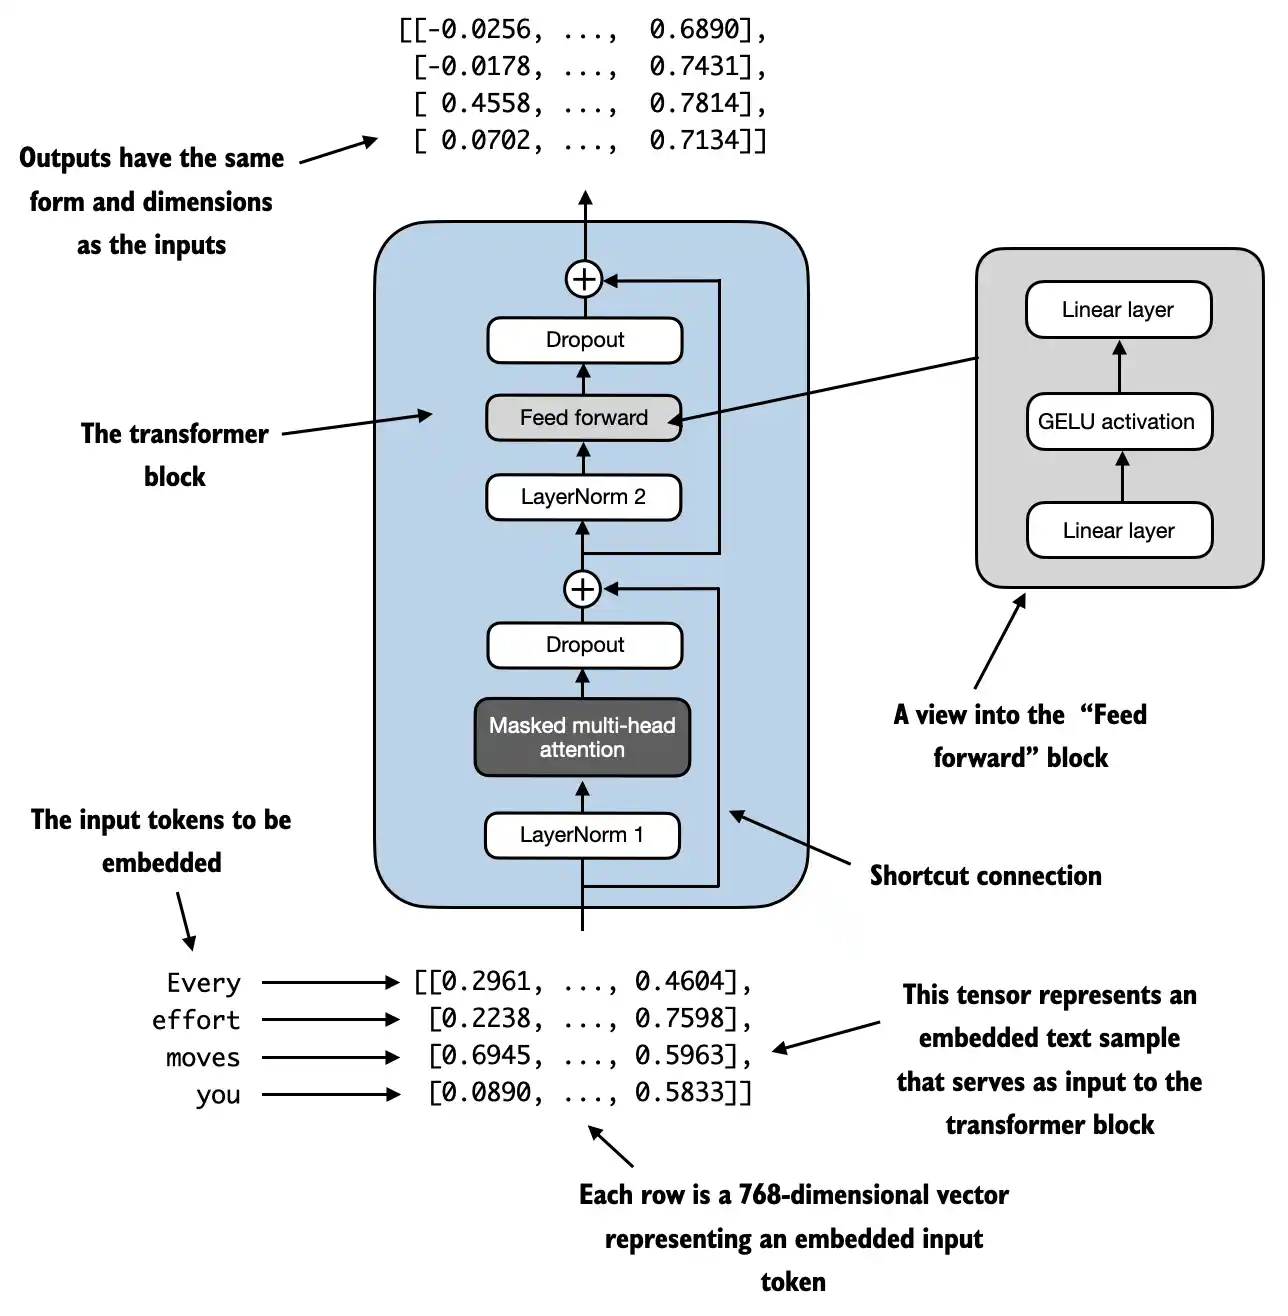

In the above diagram, it is transformer block ,have following work flow
1. Before transformer block we split our data.
2. Input it in embedding layer of 786 dimensions.
3. Then come the transformer block and repeated no. of time in GPT model,contain
**1st MODULE**

 i.  Normalization layer.

 ii. Mask Multi-Head attention module.

 iii. Dropout layer(optional).

 iv. Next we have residual/shortcut connection.

**2nd MODULE**
 i. Layer norm2

 ii. Feed Forward Layer consist of linear layer, GELU activation and another linear layer

iii. Dropout layer(optional)

- Next output of the above submodule pass to next transformer block.




In [18]:
# coding GPT Transformer

# importing sub classes from previous chapters and save in a previous_chapter.py file
# GPTDatasetV1(Dataset)and data loading function from chapter 2
# Multi Head attention class form chapter 3

from previous_chapters import MultiHeadAttention


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
# first sub module of transformer
    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back
# second sub module of transformer
        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x




In [19]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # Shape: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

# Input and output shape should be the same as we are using the output of one transformer block as the input to other transformer block
# so the shape should br same.

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


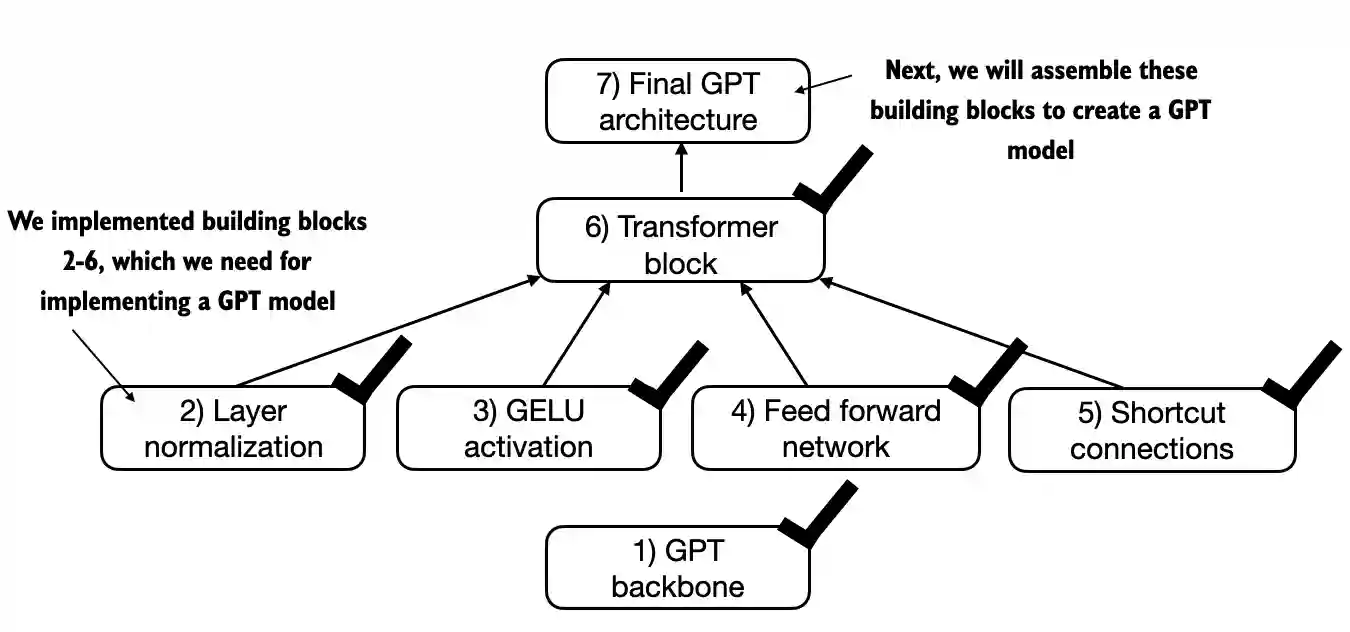

# 4.6 Coding the GPT model

We are almost there:
- now let's plug in the transformer block into the architecture we coded at the very beginning of this chapter so that we obtain a usable GPT architecture.

- Note that the transformer block is repeated multiple times; in the case of the smallest 124M GPT-2 model, we repeat it 12 times:

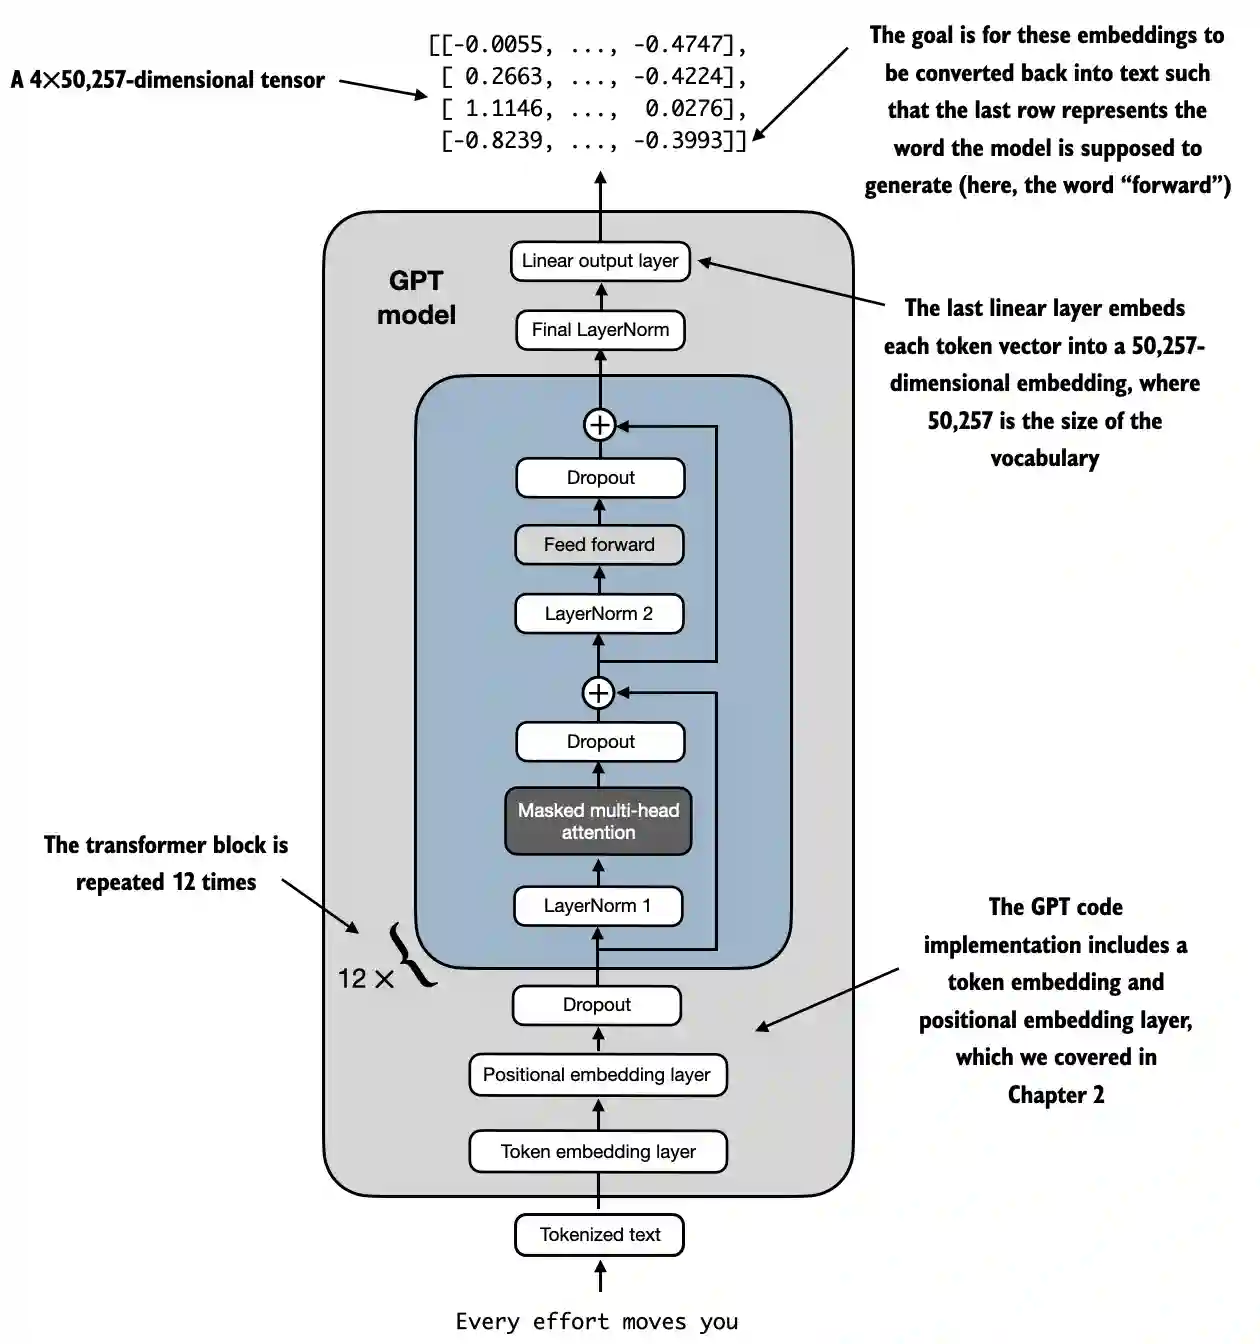

The corresponding code implementation, where cfg["n_layers"] = 12:

In [20]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


Using the configuration of the 124M parameter model, we can now instantiate this GPT model with random initial weights as follows

In [21]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.1381,  0.0077, -0.1963,  ..., -0.0222, -0.1060,  0.1717],
         [ 0.3865, -0.8408, -0.6564,  ..., -0.5163,  0.2369, -0.3357],
         [ 0.6989, -0.1829, -0.1631,  ...,  0.1472, -0.6504, -0.0056],
         [-0.4290,  0.1669, -0.1258,  ...,  1.1579,  0.5303, -0.5549]],

        [[ 0.1094, -0.2894, -0.1467,  ..., -0.0557,  0.2911, -0.2824],
         [ 0.0882, -0.3552, -0.3527,  ...,  1.2930,  0.0053,  0.1898],
         [ 0.6091,  0.4702, -0.4094,  ...,  0.7688,  0.3787, -0.1974],
         [-0.0612, -0.0737,  0.4751,  ...,  1.2463, -0.3834,  0.0609]]],
       grad_fn=<UnsafeViewBackward0>)


We will train this model in the next chapter.

However, a quick note about its size:

- we previously referred to it as a 124M parameter model; we can double check this number as follows:

In [22]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


### What Are Model Parameters?

Imagine a model like a robot that learns to understand language. To do this, the robot has a lot of "settings" or "knobs" that it can adjust. These settings are called **parameters**. More parameters usually mean the robot can learn better.

### Total Parameters

In this case, the model has **163 million** parameters. That’s a huge number! It means the robot has a lot of settings to help it learn.

### What is Weight Tying?

Now, here’s where it gets a bit tricky. When the robot learns, it uses something called **weight tying**. This is like saying, “Hey, let’s use the same tool for two jobs instead of having two different tools.”

1. **Two Jobs**:
   - The robot uses one tool (called the **embedding layer**) to turn words into numbers it can understand.
   - It uses the same tool again (the **output layer**) to change those numbers back into words.

### Why the Confusion?

Some people say the model has **124 million** parameters. This number comes from counting the settings for the robot but not counting the ones for the output layer since they are tied to the input layer.

### Summary

- **163 million**: Total settings in the robot.
- **124 million**: Unique settings when considering weight tying.
- Weight tying helps the robot learn better without needing extra tools.



================================================================================

If the robot didn’t use weight tying, here’s what would happen:

### More Parameters

1. **Extra Settings**: The robot would need separate tools (or settings) for both the embedding layer and the output layer. This means it would have a lot more parameters to manage.

### Increased Complexity

2. **Harder to Train**: With more parameters, the robot might take longer to learn because it has to adjust more settings. It could also become more complicated, making it harder to understand how it works.

### Risk of Overfitting

3. **Overfitting**: The robot might learn too much from the training data and not perform well on new data. This is like a student who memorizes answers for a test but doesn’t really understand the material.

### Larger Model Size

4. **Bigger Model**: The model would take up more space and require more memory to run. This could make it slower and less efficient.

### Conclusion

In summary, not using weight tying would make the robot more complicated, slower to train, and possibly less effective at understanding language. Weight tying helps keep things simpler and more efficient!

================================================================================

Sure! Here’s how weight tying improves efficiency in models like the one we’re discussing:

### 1. **Fewer Parameters**

- **Shared Weights**: With weight tying, the same weights are used for both the embedding layer and the output layer. This means the model has fewer unique parameters to adjust, which simplifies the learning process.
- **Reduced Complexity**: Fewer parameters make the model less complex, which helps in faster training and easier optimization.

### 2. **Memory Savings**

- **Less Memory Required**: Since the model uses the same weights, it requires less memory to store the parameters. This is especially important for large models that may be used in applications with limited resources.
- **Faster Operations**: With fewer weights to process, calculations during training and inference (when the model makes predictions) can be done more quickly.

### 3. **Improved Generalization**

- **Avoids Overfitting**: By tying weights, the model is less likely to memorize the training data too closely. This helps it generalize better to new, unseen data, making it more robust.
- **Focus on Learning**: With fewer parameters, the model can focus on learning the important features of the data rather than getting bogged down with extra settings.

### 4. **Simplified Design**

- **Easier Implementation**: Weight tying simplifies the architecture of the model, making it easier to implement and maintain. This can lead to quicker iterations and improvements in model design.
- **Consistency**: It ensures that the way words are represented (in the embedding layer) is the same way they're interpreted (in the output layer), promoting consistency in learning.

### Summary

In summary, weight tying improves efficiency by reducing the number of parameters, saving memory, enhancing generalization, and simplifying the model's design. This allows the model to learn faster and perform better while using fewer resources!

=================================================================

 while weight tying can enhance efficiency and reduce the number of parameters, it may also limit flexibility, lead to potential misalignment in representations, and complicate interpretability. It's important to evaluate the specific needs of the task when deciding whether to use weight tying.

================================================================================

Certainly! Here are some examples of tasks where using separate weights might be preferable:

### 1. **Text Classification**

- **Example**: Sentiment analysis or topic classification.
- **Reason**: The input representation (how the text is converted to embeddings) might need to differ from the output representation (the specific classes to predict), allowing for more tailored features for each task.

### 2. **Machine Translation**

- **Example**: Translating between languages with different structures (e.g., English to Japanese).
- **Reason**: The nuances of different languages may require distinct representations in the input and output layers to capture the unique grammatical and syntactical structures.

### 3. **Speech Recognition**

- **Example**: Converting spoken language to text.
- **Reason**: The features that work well for processing audio input may differ significantly from those needed for generating text output, making separate weights beneficial.

### 4. **Question Answering**

- **Example**: Extracting answers from a passage.
- **Reason**: The model may need to understand the context differently for analyzing the input text (the passage) versus generating the output (the answer), making separate weights more effective.

### 5. **Text Summarization**

- **Example**: Summarizing long articles.
- **Reason**: The features needed to understand the full article (input) may be different from those required to generate a concise summary (output), benefiting from separate weights.

### 6. **Image Captioning**

- **Example**: Generating descriptions for images.
- **Reason**: The representation of visual features from images may need to be processed differently than the text generated, necessitating separate weights for optimal performance.

### Summary

In these tasks, having separate weights allows for more flexibility and better performance by tailoring the representations specifically to the needs of input processing and output generation. This can lead to improved accuracy and effectiveness in the model's predictions.

======================================================================


As we see above, this model has 163M, not 124M parameters; why?

- In the original GPT-2 paper, the researchers applied weight tying, which means that they reused the token embedding layer (tok_emb) as the output layer, which means setting self.out_head.weight = self.tok_emb.weight

- The token embedding layer projects the 50,257-dimensional one-hot encoded input tokens to a 768-dimensional embedding representation.

- The output layer projects 768-dimensional embeddings back into a 50,257-dimensional representation so that we can convert these back into words (more about that in the next section).

- So, the embedding and output layer have the same number of weight parameters, as we can see based on the shape of their weight matrices.

However, a quick note about its size:

we previously referred to it as a 124M parameter model; we can double check this number as follows:

In [23]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [27]:
 sum(p.numel() for p in model.out_head.parameters())

38597376

In [28]:
# total paramenter = 163,009,536
# output parameter of model = 38591376
# so total parameter after weight tying will be total paremeter - output parameter because after subtracting the output parameter we get the unique paramenter only

total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


In practice, I found it easier to train the model without weight-tying, that is why we didn't implement it here.

However, we will revisit and apply this weight-tying idea later when we load the pretrained weights in chapter 5

Lastly, we can compute the memory requirements of the model as follows, which can be a helpful reference point:

In [29]:
#compute the memory requirements of the model

# Calculate the total size in bytes (assuming float32, 4 bytes per parameter)
total_size_bytes = total_params * 4

# Convert to megabytes
total_size_mb = total_size_bytes / (1024 * 1024)

print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


# 4.7 Generating text or converting vectore into words

LLMs like the GPT model we implemented above are used to generate one word at a time.

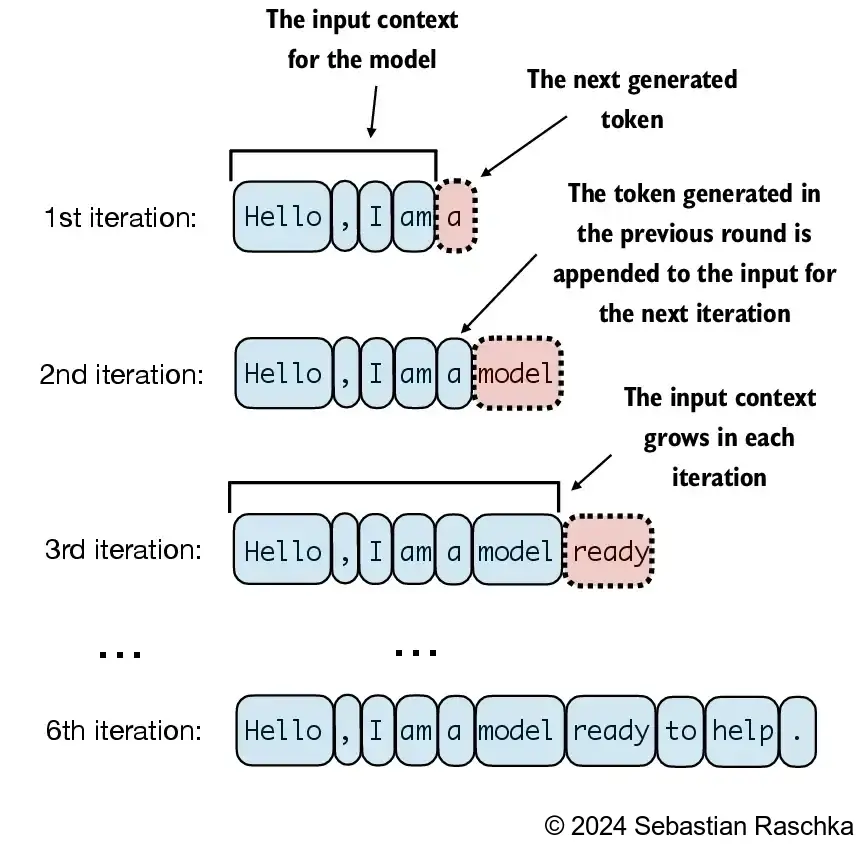

## How LLM generate tokens or text
- its an iteration process. generate one word then append it to the the sentence then generate next word in next iteration.

- The following `generate_text_simple` function implements greedy decoding, which is a simple and fast method to generate text.

- In greedy decoding, at each step, the model chooses the word (or token) with the highest probability as its next output (the highest logit corresponds to the highest probability, so we technically wouldn't even have to compute the softmax function explicitly).

- In the next chapter, we will implement a more advanced `generate_text` function
The figure below depicts how the GPT model, given an input context, generates the next word token

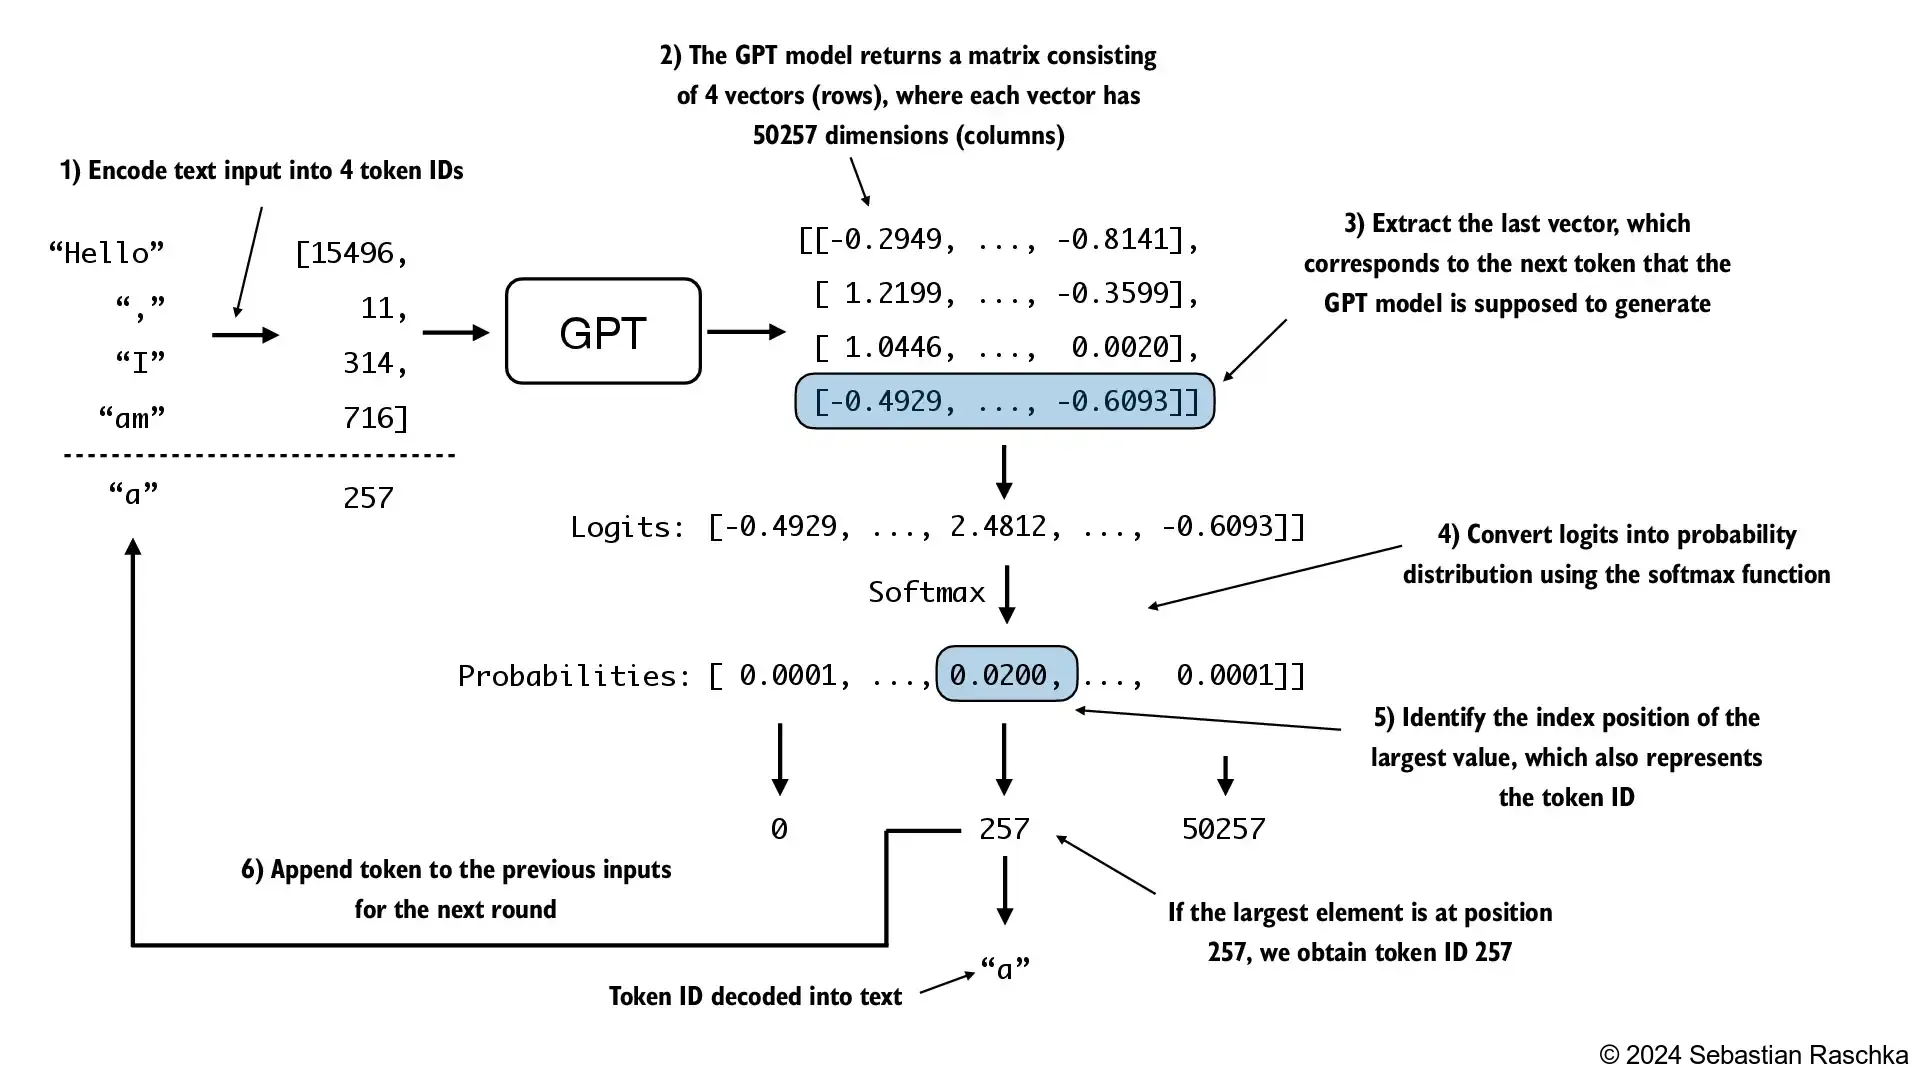

In [34]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]     #Select All Rows: The first part (:) indicates that we want to include every row in the idx array.
                                              #Select Last context_size Columns: The second part (-context_size:)
                                              #specifies that we want to take only the last context_size columns from each row.

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

The `generate_text_simple` above implements an iterative process, where it creates one token at a time.




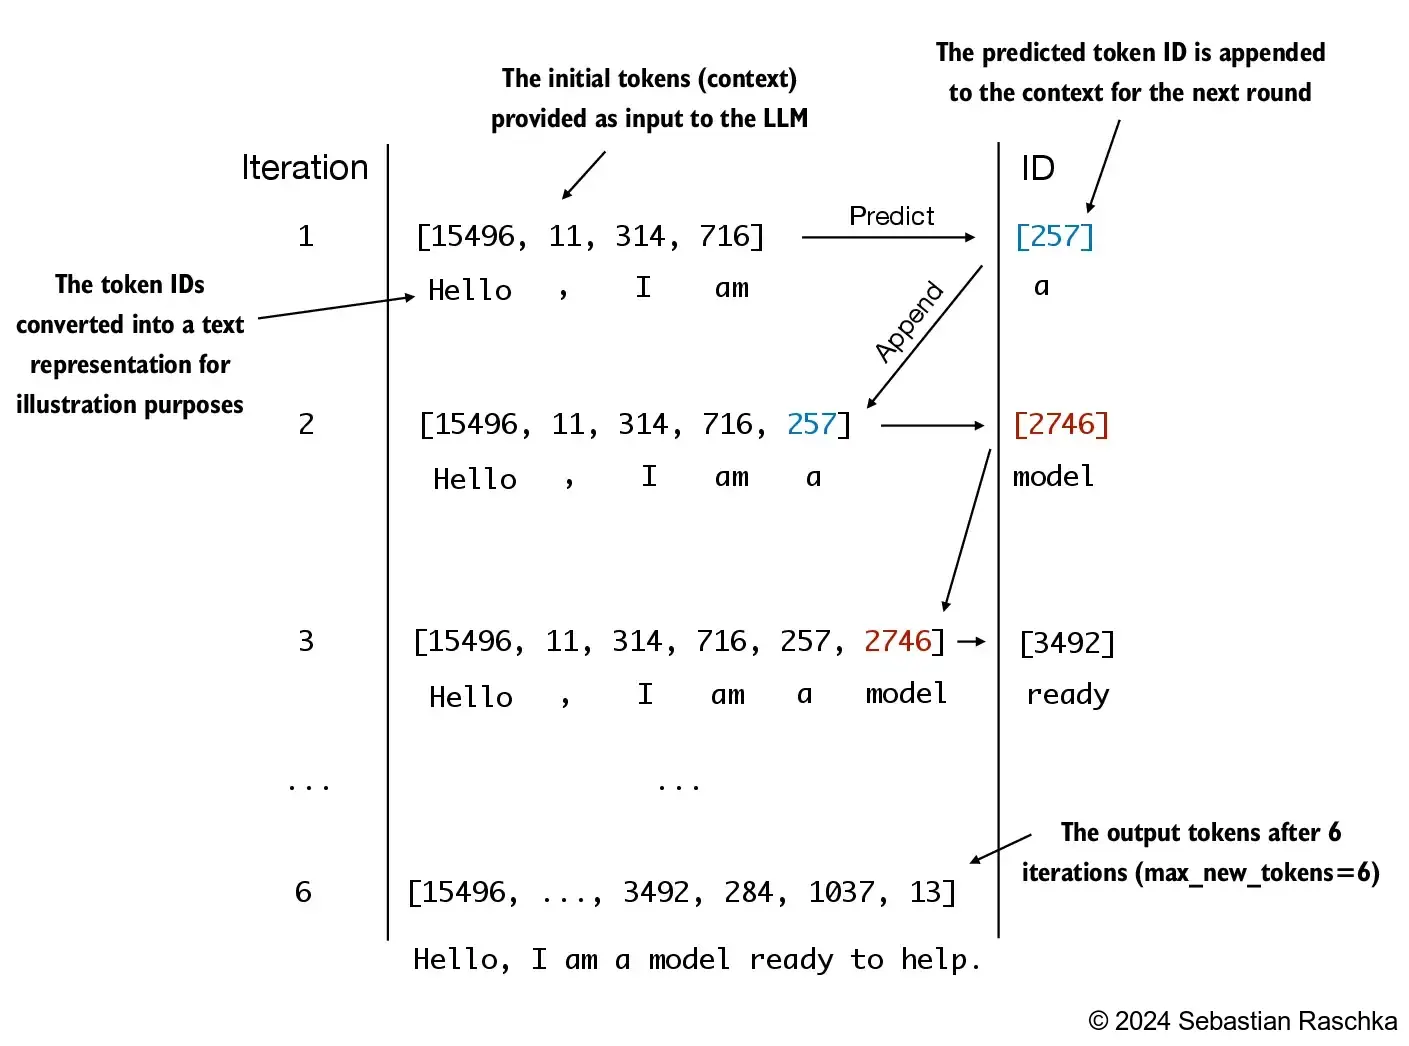

Let’s break down the provided code step by step to understand its functionality, primarily in the context of generating predictions using a neural network model, likely for a sequence-based task such as language generation.

### Code Breakdown

1. **Get the Predictions**:
    ```python
    with torch.no_grad():
        logits = model(idx_cond)
    ```
   - Here, `torch.no_grad()` is used to disable gradient calculation, which reduces memory usage and speeds up computations during inference.
   - The `model(idx_cond)` call passes the input tensor `idx_cond` (which contains the last `context_size` tokens) through the model to obtain `logits`. These logits represent the raw output scores for each token in the vocabulary.

2. **Focus Only on the Last Time Step**:
    ```python
    logits = logits[:, -1, :]
    ```
   - This line extracts the logits corresponding to the last time step in the sequence. The shape changes from `(batch, n_tokens, vocab_size)` to `(batch, vocab_size)`, meaning we are only interested in the predictions for the most recent token.

3. **Apply Softmax to Get Probabilities**:
    ```python
    probas = torch.softmax(logits, dim=-1)
    ```
   - The softmax function converts the logits into probabilities. Each value in `probas` now represents the probability of each token in the vocabulary being the next token in the sequence. The output shape remains `(batch, vocab_size)`.

4. **Get the Index of the Vocabulary Entry with the Highest Probability**:
    ```python
    idx_next = torch.argmax(probas, dim=-1, keepdim=True)
    ```
   - `torch.argmax` finds the index of the maximum probability in each row (for each batch). This gives us `idx_next`, which has the shape `(batch, 1)`, indicating the index of the most likely next token.

5. **Append Sampled Index to the Running Sequence**:
    ```python
    idx = torch.cat((idx, idx_next), dim=1)
    ```
   - This line concatenates `idx_next` to the existing sequence `idx`, effectively adding the predicted next token to the sequence. The resulting shape of `idx` is now `(batch, n_tokens + 1)`.

6. **Return the Updated Sequence**:
    ```python
    return idx
    ```
   - Finally, the function returns the updated index tensor containing the original sequence plus the newly predicted token.

### Summary

This code snippet is commonly used in language generation tasks. The model predicts the next token based on the most recent context, calculates probabilities, selects the token with the highest probability, and appends it to the input sequence for further predictions. This process typically repeats in a loop until a stopping condition is met (e.g., reaching a maximum sequence length or generating an end-of-sequence token).


Get the predictions

```
with torch.no_grad():
    logits = model(idx_cond)  # Pass the input (last context tokens) through the model to get raw scores.
```
Focus only on the last time step

(batch, n_tokens, vocab_size) becomes (batch, vocab_size)



```
logits = logits[:, -1, :]  # Select predictions for the last token in each batch.
```

 Apply softmax to get probabilities

```
probas = torch.softmax(logits, dim=-1)  # Convert logits to probabilities across the vocabulary.
```

 Get the idx of the vocab entry with the highest probability value


```
idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # Find the index of the token with the highest probability.
```

Append sampled index to the running sequence



```
idx = torch.cat((idx, idx_next), dim=1)  
```
 Concatenate the predicted token to the existing sequence.

```
return idx  
```
Return the updated sequence with the newly predicted token.



```

In [31]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [32]:
model.eval() # disable dropout

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


Remove batch dimension and convert back into text:

In [33]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue
